In [4]:
# ===================================================
# Fine-Tuning Results Analysis Notebook
# Purpose: Analyze GA fine tuning results
# ===================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [5]:
# Experiment_Pipeline\simple_fine_tuning\results\joint\joint_summary.csv

RESULTS_PATH = Path().resolve() / "joint_summary.csv"

df = pd.read_csv(RESULTS_PATH)
print("✅ CSV Loaded:", RESULTS_PATH)
print(df.head())
print(df.columns)

✅ CSV Loaded: C:\Users\57305\Downloads\FTZ_model_2.0\paper_results\fine_tuning\individual_algorithm_results\joint\joint_summary.csv
    algo  candidate_id  seed  best_final   auc_best  auc_best_norm  \
0  joint           100  1001      438.65  43859.075      438.59075   
1  joint           100   101      438.65  43863.350      438.63350   
2  joint           100  1102      438.65  43862.675      438.62675   
3  joint           100   202      438.65  43862.075      438.62075   
4  joint           100   303      438.65  43861.775      438.61775   

   runtime_sec  evals_total  budget_triggered  stop_reason  cxpb  mutpb  \
0    84.069013         1822             False          NaN   NaN    NaN   
1    80.820975         1822             False          NaN   NaN    NaN   
2    93.866649         1822             False          NaN   NaN    NaN   
3    81.028252         1822             False          NaN   NaN    NaN   
4    88.198264         1822             False          NaN   NaN    NaN 

In [6]:
# ---------------------------------------------------
# 2) Sort + Inspect Best Runs (with full hyperparams)
# ---------------------------------------------------

df_sorted = df.sort_values(
    by=["best_final", "auc_best_norm"],
    ascending=[False, False],
    na_position="last"
)

TOP_N = 10 

cols_to_show = [
    
    "algo", "candidate_id", "seed",
    
    
    "best_final", "auc_best_norm", "runtime_sec",
    
    
    "cxpb", "mutpb", "mutation_rate",
    "parents_rate", "sel_mutation", "tail_mutation"
]

print(f"\n🏆 Top {TOP_N} Joint GA Runs (Metrics + Hyperparams):")
display(df_sorted[cols_to_show].head(TOP_N).style.background_gradient(cmap="viridis"))

# Best explicit
best_row = df_sorted.iloc[0]
print("\n✅ BEST RUN SELECTED:")
display(best_row[cols_to_show])



🏆 Top 10 Joint GA Runs (Metrics + Hyperparams):


c:\Users\57305\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\io\formats\style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
c:\Users\57305\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\io\formats\style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,algo,candidate_id,seed,best_final,auc_best_norm,runtime_sec,cxpb,mutpb,mutation_rate,parents_rate,sel_mutation,tail_mutation
208,joint,26,909,438.650000,438.638750,95.861005,nan,nan,nan,0.198740,0.178754,0.119286
824,joint,77,909,438.650000,438.638750,96.113698,nan,nan,nan,0.158281,0.434271,0.127600
5,joint,100,404,438.650000,438.634250,92.141308,nan,nan,nan,0.223424,0.332323,0.021376
412,joint,43,404,438.650000,438.634250,105.458522,nan,nan,nan,0.125474,0.123674,0.093971
1,joint,100,101,438.650000,438.633500,80.820975,nan,nan,nan,0.223424,0.332323,0.021376
160,joint,22,505,438.650000,438.633500,104.405488,nan,nan,nan,0.100579,0.477344,0.052250
320,joint,36,101,438.650000,438.633500,94.235852,nan,nan,nan,0.211821,0.468957,0.046030
126,joint,1,404,438.650000,438.632750,86.299065,nan,nan,nan,0.146225,0.166118,0.065189
164,joint,22,909,438.650000,438.632750,102.084918,nan,nan,nan,0.100579,0.477344,0.052250
466,joint,48,303,438.650000,438.632750,76.909096,nan,nan,nan,0.250610,0.155499,0.036432



✅ BEST RUN SELECTED:


algo                 joint
candidate_id            26
seed                   909
best_final          438.65
auc_best_norm    438.63875
runtime_sec      95.861005
cxpb                   NaN
mutpb                  NaN
mutation_rate          NaN
parents_rate       0.19874
sel_mutation      0.178754
tail_mutation     0.119286
Name: 208, dtype: object

In [12]:
# =======================================================
# Aggregation by Candidate (11 seeds per candidate)
# =======================================================

agg = df.groupby("candidate_id").agg({
    "best_final": ["mean", "max"],
    "auc_best_norm": ["mean", "max"],
    "runtime_sec": "mean",
    "evals_total": "mean",
    "seed": "count",
    "parents_rate": "mean",
    "sel_mutation": "mean",
    "tail_mutation": "mean" # sanity check: should be 11
})

# Flatten MultiIndex columns
agg.columns = [
    f"{m}_{s}" if s != "" else m
    for m, s in agg.columns.map(lambda x: (x[0], "" if x[1] == "" else x[1]))
]

# Order by best performance + best stability
agg_sorted = agg.sort_values(
    by=["best_final_max", "auc_best_norm_mean"],
    ascending=[False, False]
)

print("✅ Aggregated results by candidate:")
display(agg_sorted.head(10))

✅ Aggregated results by candidate:


,best_final_mean,best_final_max,auc_best_norm_mean,auc_best_norm_max,runtime_sec_mean,evals_total_mean,seed_count,parents_rate_mean,sel_mutation_mean,tail_mutation_mean
candidate_id,,,,,,,,,,
5,438.65,438.65,438.621705,438.63125,79.125843,1822.0,11,0.214169,0.440700,0.081783
36,438.65,438.65,438.618841,438.63350,90.808059,1822.0,11,0.211821,0.468957,0.046030
77,438.65,438.65,438.617750,438.63875,93.558763,1922.0,11,0.158281,0.434271,0.127600
22,438.65,438.65,438.617750,438.63350,102.421189,2022.0,11,0.100579,0.477344,0.052250
43,438.65,438.65,438.616795,438.63425,98.401792,2022.0,11,0.125474,0.123674,0.093971
95,438.65,438.65,438.612159,438.63125,89.625943,1822.0,11,0.192396,0.354814,0.076521
100,438.65,438.65,438.610523,438.63425,87.564389,1822.0,11,0.223424,0.332323,0.021376
85,438.65,438.65,438.610250,438.62975,99.481007,1922.0,11,0.140801,0.343919,0.131676
76,438.65,438.65,438.609295,438.62900,88.021629,1822.0,11,0.189127,0.171513,0.032920


In [13]:
# =======================================================
# Aggregation by Candidate 2 (11 seeds per candidate)
# =======================================================

agg = df.groupby("candidate_id").agg({
    "best_final": ["mean", "max"],
    "auc_best_norm": ["mean", "max"],
    "runtime_sec": "mean",
    "evals_total": "mean",
    "seed": "count",
    "parents_rate": "mean",
    "sel_mutation": "mean",
    "tail_mutation": "mean" # sanity check: should be 11
})

# Flatten MultiIndex columns
agg.columns = [
    f"{m}_{s}" if s != "" else m
    for m, s in agg.columns.map(lambda x: (x[0], "" if x[1] == "" else x[1]))
]

# Order by best performance + best stability
agg_sorted = agg.sort_values(
    by=["best_final_max", "auc_best_norm_max"],
    ascending=[False, False]
)

print("✅ Aggregated results by candidate:")
display(agg_sorted.head(10))

✅ Aggregated results by candidate:


,best_final_mean,best_final_max,auc_best_norm_mean,auc_best_norm_max,runtime_sec_mean,evals_total_mean,seed_count,parents_rate_mean,sel_mutation_mean,tail_mutation_mean
candidate_id,,,,,,,,,,
26,438.65,438.65,438.607523,438.63875,93.506717,1822.0,11,0.198740,0.178754,0.119286
77,438.65,438.65,438.617750,438.63875,93.558763,1922.0,11,0.158281,0.434271,0.127600
43,438.65,438.65,438.616795,438.63425,98.401792,2022.0,11,0.125474,0.123674,0.093971
100,438.65,438.65,438.610523,438.63425,87.564389,1822.0,11,0.223424,0.332323,0.021376
22,438.65,438.65,438.617750,438.63350,102.421189,2022.0,11,0.100579,0.477344,0.052250
36,438.65,438.65,438.618841,438.63350,90.808059,1822.0,11,0.211821,0.468957,0.046030
1,438.65,438.65,438.607932,438.63275,86.134001,1922.0,11,0.146225,0.166118,0.065189
48,438.65,438.65,438.602205,438.63275,83.849942,1722.0,11,0.250610,0.155499,0.036432
5,438.65,438.65,438.621705,438.63125,79.125843,1822.0,11,0.214169,0.440700,0.081783


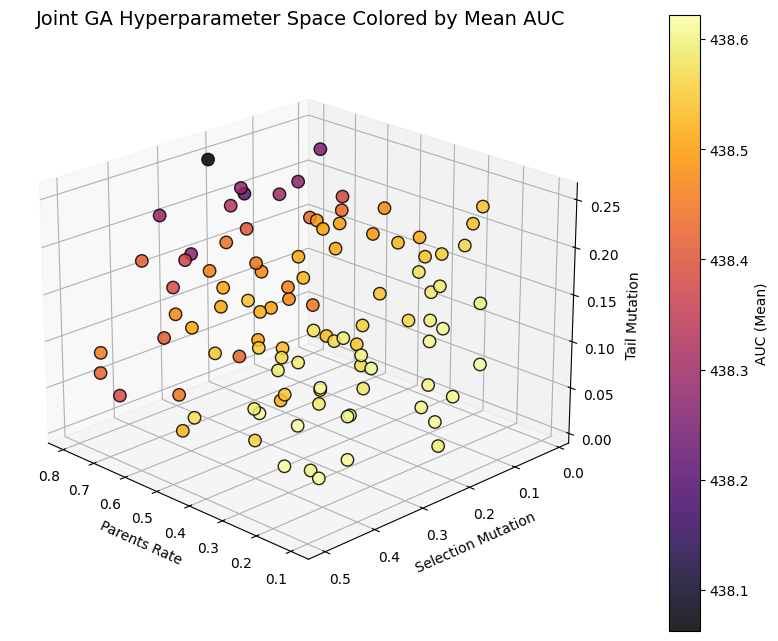

In [14]:
# ==================================================================
# 3D Scatter Plot with AUC Heatmap Coloring
# ==================================================================

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting
import seaborn as sns  # Optional for consistent style

# Data source
# Each variable represents the mean value of a hyperparameter configuration
x_parents_rate = agg_sorted["parents_rate_mean"]
y_selection_mutation = agg_sorted["sel_mutation_mean"]
z_tail_mutation = agg_sorted["tail_mutation_mean"]
auc_mean = agg_sorted["auc_best_norm_mean"]  # 🔥 Color represents mean AUC performance

# Create figure and 3D axis
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# 3D scatter plot with heatmap-style coloring
scatter = ax.scatter(
    x_parents_rate,
    y_selection_mutation,
    z_tail_mutation,
    c=auc_mean,             # Color points by AUC
    cmap="inferno",         # 🔥 Same color palette as your example
    s=80,                   # Point size
    alpha=0.85,             # Transparency
    edgecolors="black"      # Outline color
)

# Axis labels and title
ax.set_xlabel("Parents Rate")
ax.set_ylabel("Selection Mutation")
ax.set_zlabel("Tail Mutation")
ax.set_title("Joint GA Hyperparameter Space Colored by Mean AUC", fontsize=14)

# Add colorbar to represent AUC values
colorbar = fig.colorbar(scatter, ax=ax, pad=0.1)
colorbar.set_label("AUC (Mean)")

# Optional: Adjust 3D viewing angle for better visualization
ax.view_init(elev=22, azim=135)

# Display the plot
plt.show()


ValueError: Could not interpret value `auc_best_norm_mean` for `hue`. An entry with this name does not appear in `data`.

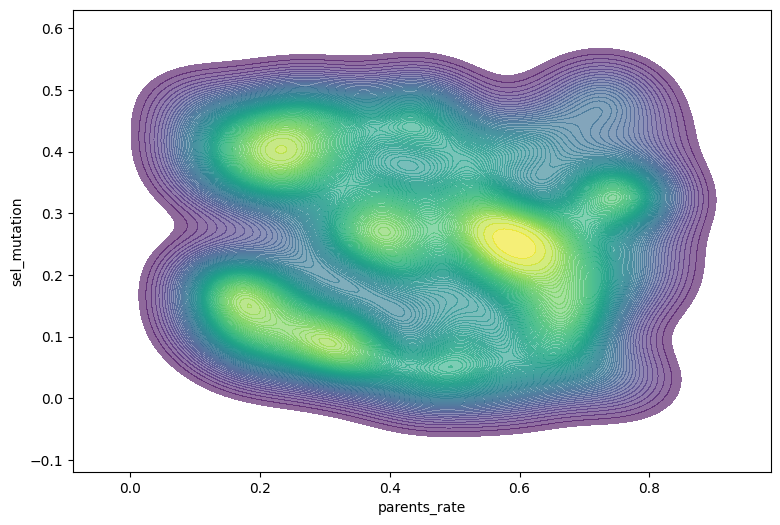

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))

# KDE density background (soft, non-saturating)
sns.kdeplot(
    data=df,
    x="parents_rate", y="sel_mutation",
    fill=True,
    cmap="viridis",
    levels=100,
    alpha=0.6,
    thresh=0.02
)

# Scatter of AUC values (colored by performance)
sns.scatterplot(
    data=df,
    x="parents_rate", y="sel_mutation",
    hue="auc_best_norm_mean",
    palette="viridis",
    edgecolor="black",
    linewidth=0.3,
    s=45,
    alpha=0.9
)

# Colorbar replacement for the hue
norm = plt.Normalize(df["auc_best_norm_mean"].min(), df["auc_best_norm_mean"].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label("Normalized AUC", fontsize=10)

# Labels and aesthetics
plt.title("Promising regions in the hyperparameter space (parents_rate vs sel_mutation)",
          fontsize=12, pad=15)
plt.xlabel("parents_rate", fontsize=10)
plt.ylabel("sel_mutation", fontsize=10)

# Axis ranges adjusted to data
plt.xlim(df["parents_rate"].min() - 0.01, df["parents_rate"].max() + 0.01)
plt.ylim(df["sel_mutation"].min() - 0.01, df["sel_mutation"].max() + 0.01)

# Clean legend and layout
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.show()


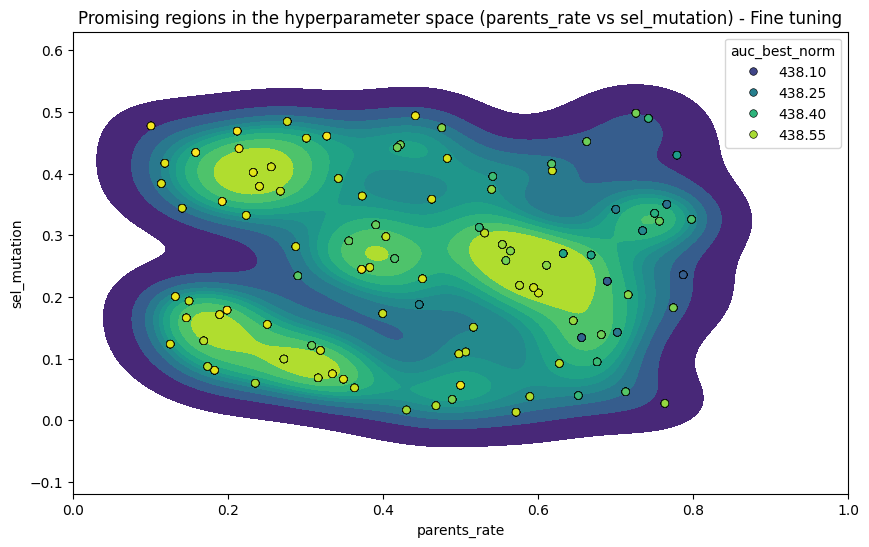

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
# Assuming 'df' is your DataFrame

plt.figure(figsize=(10,6))
sns.kdeplot(
    data=df,
    x="parents_rate", y="sel_mutation",
    fill=True, cmap="viridis", thresh=0.05
)
sns.scatterplot(
    data=df,
    x="parents_rate", y="sel_mutation",
    hue="auc_best_norm",  # <--- CORRECTED COLUMN NAME
    palette="viridis",
    edgecolor="black", s=30
)
plt.xlim(0, 1)
plt.title("Promising regions in the hyperparameter space (parents_rate vs sel_mutation) - Fine tuning")
plt.show()

In [18]:
df.columns

Index(['algo', 'candidate_id', 'seed', 'best_final', 'auc_best',
       'auc_best_norm', 'runtime_sec', 'evals_total', 'budget_triggered',
       'stop_reason', 'cxpb', 'mutpb', 'mutation_rate', 'parents_rate',
       'sel_mutation', 'tail_mutation', 'c1', 'c2', 'w', 'error'],
      dtype='object')

In [ ]:
import os
import json
import pandas as pd


results_dir = Path().resolve() / "runs"


records = []


for file in os.listdir(results_dir):
    if file.endswith(".json"):
        file_path = os.path.join(results_dir, file)
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        
        h = data.get("hparams", {})
        m = data.get("metrics", {})
        d = data.get("diagnostics", {})
        meta = data.get("meta", {})

        record = {
            "candidate_id": data.get("candidate_id"),
            "seed": data.get("seed"),
            "algo": data.get("algo"),

            
            "best_final": m.get("best_final"),
            "auc_best": m.get("auc_best"),
            "auc_best_norm": m.get("auc_best_norm"),
            "runtime_sec": m.get("runtime_sec"),
            "evals_total": m.get("evals_total"),
            "budget_triggered": m.get("budget_triggered"),

            
            "delta_abs_best": d.get("best", {}).get("delta_abs"),
            "delta_rel_best": d.get("best", {}).get("delta_rel"),

            
            "parents_rate": h.get("parents_rate"),
            "sel_mutation": h.get("sel_mutation"),
            "tail_mutation": h.get("tail_mutation"),
            "popsize": h.get("popsize"),
            "generations": h.get("generations"),

            
            "L_used": meta.get("L_used"),
            "runtime_sec_meta": meta.get("runtime_sec"),
        }

        records.append(record)


df_finetuning = pd.DataFrame(records)


df_finetuning = df_finetuning.sort_values(by=["candidate_id", "seed"]).reset_index(drop=True)


print(f"✅ {len(df_finetuning)} resultados cargados.")
display(df_finetuning.head())

✅ 1100 resultados cargados.


,candidate_id,seed,algo,best_final,auc_best,auc_best_norm,runtime_sec,evals_total,budget_triggered,delta_abs_best,delta_rel_best,parents_rate,sel_mutation,tail_mutation,popsize,generations,L_used,runtime_sec_meta
0,1,101,joint,438.65,43861.700,438.61700,83.607166,1922,False,1.50,0.003431,0.146225,0.166118,0.065189,22,100,33,83.607166
1,1,202,joint,438.65,43862.675,438.62675,85.623544,1922,False,1.95,0.004465,0.146225,0.166118,0.065189,22,100,33,85.623544
2,1,303,joint,438.65,43860.575,438.60575,87.135755,1922,False,1.95,0.004465,0.146225,0.166118,0.065189,22,100,33,87.135755
3,1,404,joint,438.65,43863.275,438.63275,86.299065,1922,False,1.65,0.003776,0.146225,0.166118,0.065189,22,100,33,86.299065
4,1,505,joint,438.65,43860.200,438.60200,87.369545,1922,False,1.50,0.003431,0.146225,0.166118,0.065189,22,100,33,87.369545


In [20]:
from scipy.stats import kruskal

# Comparar distribuciones de rendimiento entre candidatos
kruskal_result = kruskal(
    *[group["auc_best_norm"].values for _, group in df_finetuning.groupby("candidate_id")]
)
print(kruskal_result)


KruskalResult(statistic=np.float64(903.6268088173832), pvalue=np.float64(4.536670761201214e-130))


In [21]:
import pandas as pd
import numpy as np
from scipy.stats import rankdata, kruskal

# Métrica base
metric = "auc_best_norm"


groups = [g[metric].values for _, g in df_finetuning.groupby("candidate_id")]
kruskal_result = kruskal(*groups)

print(f"Kruskal–Wallis H = {kruskal_result.statistic:.3f}, p = {kruskal_result.pvalue:.3e}")


Kruskal–Wallis H = 903.627, p = 4.537e-130


In [22]:
# Añade los ranks globales (rangos de menor a mayor)
df_finetuning["rank"] = rankdata(df_finetuning[metric])

# Promedio de rangos por candidato
rank_means = (
    df_finetuning.groupby("candidate_id")["rank"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=False)
)

rank_means["rank_mean_diff"] = rank_means["mean"] - rank_means["mean"].mean()
display(rank_means.head(10))


,mean,std,count,rank_mean_diff
candidate_id,,,,
5,1041.136364,33.553011,11,490.636364
36,1017.363636,77.538084,11,466.863636
77,1012.727273,57.188444,11,462.227273
22,1012.272727,58.049704,11,461.772727
43,998.090909,100.139857,11,447.590909
95,975.909091,88.967921,11,425.409091
85,961.136364,93.122793,11,410.636364
100,958.500000,128.654965,11,408.000000
76,955.500000,100.254676,11,405.000000


C:\Users\57305\AppData\Local\Temp\ipykernel_25392\1956072112.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


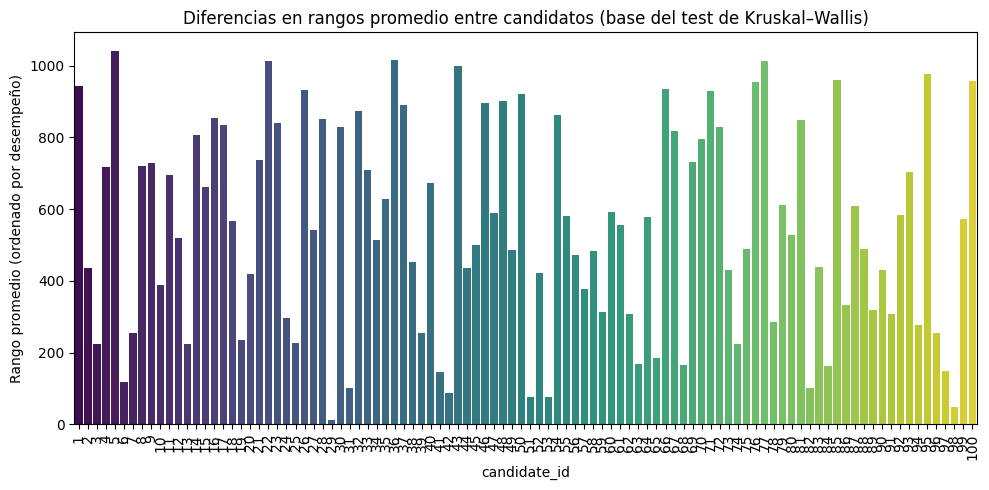

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(
    x=rank_means.index,
    y="mean",
    data=rank_means,
    palette="viridis"
)
plt.xticks(rotation=90)
plt.ylabel("Rango promedio (ordenado por desempeño)")
plt.title("Diferencias en rangos promedio entre candidatos (base del test de Kruskal–Wallis)")
plt.tight_layout()
plt.show()


C:\Users\57305\AppData\Local\Temp\ipykernel_25392\759400793.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


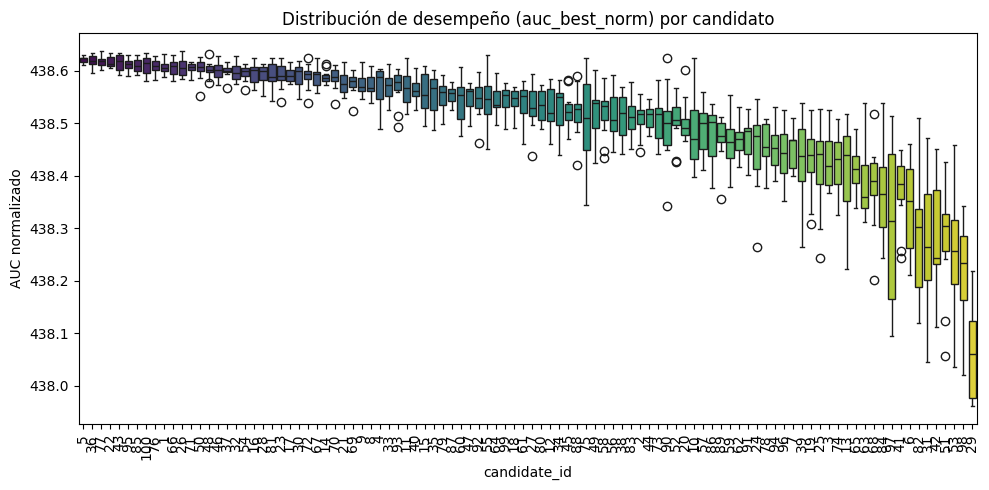

In [24]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_finetuning,
    x="candidate_id",
    y="auc_best_norm",
    order=rank_means.index,  # ordenados por rango promedio
    palette="viridis"
)
plt.xticks(rotation=90)
plt.title("Distribución de desempeño (auc_best_norm) por candidato")
plt.ylabel("AUC normalizado")
plt.tight_layout()
plt.show()


In [25]:
import pandas as pd
from scipy.stats import mannwhitneyu

# --- Filtramos la métrica de interés ---
metric = "auc_best_norm"

# Agrupamos por candidato
groups = {cid: g[metric].values for cid, g in df_finetuning.groupby("candidate_id")}

# Generamos todas las combinaciones de pares (sin repetición)
pairs = list(itertools.combinations(groups.keys(), 2))

# Ejecutamos Mann-Whitney U para cada par (una-sided: "greater" → c1 > c2)
results = []
for c1, c2 in pairs:
    stat, p = mannwhitneyu(groups[c1], groups[c2], alternative="greater")
    results.append({
        "comparison": f"{c1} > {c2}",
        "n_c1": len(groups[c1]),
        "n_c2": len(groups[c2]),
        "statistic": stat,
        "p_value": p
    })

df_wilcoxon = pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)

# Aplicamos Bonferroni para corregir comparaciones múltiples
df_wilcoxon["p_adj_bonferroni"] = df_wilcoxon["p_value"] * len(df_wilcoxon)
df_wilcoxon["significant"] = df_wilcoxon["p_adj_bonferroni"] < 0.05

display(df_wilcoxon.head(50))


NameError: name 'itertools' is not defined

In [26]:
df_wilcoxon[df_wilcoxon["significant"]]


NameError: name 'df_wilcoxon' is not defined

In [ ]:
df_wilcoxon.sort_values("p_value", ascending=True)
df_wilcoxon.sort_values("statistic", ascending=False)


,comparison,n_c1,n_c2,statistic,p_value,p_adj_bonferroni,significant
0,28 > 94,11,11,121.0,0.00004,0.197115,False
1,28 > 68,11,11,121.0,0.00004,0.198035,False
2,28 > 51,11,11,121.0,0.00004,0.198035,False
3,28 > 65,11,11,121.0,0.00004,0.198035,False
4,28 > 84,11,11,121.0,0.00004,0.198035,False
...,...,...,...,...,...,...,...
4945,19 > 28,11,11,0.0,0.99997,4949.849783,False
4946,25 > 28,11,11,0.0,0.99997,4949.849783,False
4947,3 > 28,11,11,0.0,0.99997,4949.849783,False
4948,24 > 28,11,11,0.0,0.99997,4949.849783,False


In [27]:
plt.figure(figsize=(10,4))
sns.histplot(df_wilcoxon["p_value"], bins=30)
plt.axvline(0.05, color="red", linestyle="--", label="α = 0.05")
plt.legend()
plt.title("Distribución de p-values (Mann–Whitney U tests)")
plt.show()


NameError: name 'df_wilcoxon' is not defined

<Figure size 1000x400 with 0 Axes>

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Creamos una matriz vacía de tamaño candidatos × candidatos
candidates = sorted(df_wilcoxon['comparison']
                    .str.extract(r'(\d+)')[0].astype(int).unique())
matrix = pd.DataFrame(1.0, index=candidates, columns=candidates)

# Rellenamos con los p-values ajustados
for _, row in df_wilcoxon.iterrows():
    c1, c2 = map(int, row['comparison'].split(' > '))
    matrix.loc[c1, c2] = row['p_adj_bonferroni']

# Visualizamos
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=False, cmap="viridis_r", vmin=0, vmax=1, cbar_kws={"label": "p-value (Bonferroni adjusted)"})
plt.title("Pairwise Mann–Whitney (Wilcoxon rank-sum) tests between candidates")
plt.xlabel("Candidate j")
plt.ylabel("Candidate i (i > j)")
plt.show()


NameError: name 'df_wilcoxon' is not defined

In [29]:
import numpy as np
import pandas as pd
from scipy.stats import t

# --- Métrica principal ---
metric = "auc_best_norm"

# --- Cálculo por candidato ---
g = df_finetuning.groupby("candidate_id")[metric]
mean = g.mean()
std  = g.std(ddof=1)
n    = g.count()
se   = std / np.sqrt(n)

# t crítico por candidato (por si algún candidato no tiene exactamente 11 seeds)
tcrit = t.ppf(1 - 0.05, df=(n - 1).clip(lower=1))  # unilateral 95%
lcb95 = mean - tcrit * se

df_lcb = (
    pd.DataFrame({"auc_mean": mean, "auc_std": std, "n": n, "se": se, "lcb95": lcb95})
    .sort_values("lcb95", ascending=False)
)

# --- Shortlist: top K por LCB95 (ajusta top a conveniencia) ---
top = 10
short_candidates = df_lcb.head(top).index.tolist()

print("Shortlist (top por LCB95):", short_candidates)
display(df_lcb.head(top))


Shortlist (top por LCB95): [5, 77, 36, 22, 43, 95, 85, 76, 1, 100]


,auc_mean,auc_std,n,se,lcb95
candidate_id,,,,,
5,438.621705,0.006222,11,0.001876,438.618304
77,438.617750,0.010068,11,0.003036,438.612248
36,438.618841,0.012155,11,0.003665,438.612198
22,438.617750,0.010343,11,0.003119,438.612098
43,438.616795,0.015596,11,0.004702,438.608273
95,438.612159,0.012953,11,0.003905,438.605081
85,438.610250,0.013141,11,0.003962,438.603069
76,438.609295,0.013959,11,0.004209,438.601667
1,438.607932,0.013250,11,0.003995,438.600691


In [30]:
import itertools
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

alpha = 0.05

# Matriz seed × candidate (para parear por seed)
pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)

pairs = list(itertools.combinations(short_candidates, 2))
rows = []
for c1, c2 in pairs:
    data = pivot[[c1, c2]].dropna()
    if len(data) < 5:
        continue
    diff = data[c1] - data[c2]
    # H1: c1 > c2
    stat, p = wilcoxon(diff, alternative="greater", zero_method="pratt")
    rows.append({"c1": c1, "c2": c2, "n_seeds": len(data), "statistic": stat, "p_value": p})

df_tests = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)

# Corrección Holm (recomendada)
rej_holm, p_holm, _, _ = multipletests(df_tests["p_value"], alpha=alpha, method="holm")
df_tests["p_holm"] = p_holm
df_tests["significant_holm"] = rej_holm

# (Opcional) Bonferroni, clipeado a 1
df_tests["p_bonf"] = np.minimum(df_tests["p_value"] * len(df_tests), 1.0)
df_tests["significant_bonf"] = df_tests["p_bonf"] < alpha

display(df_tests.head(20))


,c1,c2,n_seeds,statistic,p_value,p_holm,significant_holm,p_bonf,significant_bonf
0,5,76,11,65.0,0.000977,0.043945,True,0.043945,True
1,5,1,11,63.0,0.002441,0.107422,False,0.109863,False
2,5,95,11,62.0,0.003418,0.146973,False,0.153809,False
3,36,76,11,60.0,0.005859,0.246094,False,0.263672,False
4,36,1,11,59.0,0.009277,0.380371,False,0.417480,False
5,5,85,11,57.5,0.013184,0.527344,False,0.593262,False
6,5,100,11,57.0,0.015625,0.609375,False,0.703125,False
7,36,95,11,55.0,0.022461,0.853516,False,1.000000,False
8,77,1,11,55.0,0.026855,0.993652,False,1.000000,False
9,22,1,11,53.5,0.032227,1.000000,False,1.000000,False


In [31]:
# Resumen de victorias/derrotas dentro del shortlist
cands = sorted(set(df_tests["c1"]).union(df_tests["c2"]))
summary = pd.DataFrame(index=cands, columns=["wins","losses"], data=0)

for _, row in df_tests.iterrows():
    if row["significant_holm"]:
        summary.loc[row["c1"], "wins"]  += 1
        summary.loc[row["c2"], "losses"] += 1

summary["net_wins"] = summary["wins"] - summary["losses"]
summary["win_rate"] = summary["wins"] / (summary["wins"] + summary["losses"] + 1e-9)
summary = summary.sort_values(["win_rate","net_wins","wins"], ascending=[False, False, False])

display(summary)


,wins,losses,net_wins,win_rate
5,1,0,1,1.0
1,0,0,0,0.0
22,0,0,0,0.0
36,0,0,0,0.0
43,0,0,0,0.0
77,0,0,0,0.0
85,0,0,0,0.0
95,0,0,0,0.0
100,0,0,0,0.0
76,0,1,-1,0.0


In [32]:
# Toma los dos mejores del ranking de victorias; si no hay wins, usa top-2 por LCB95
if len(summary) >= 2 and summary["wins"].sum() > 0:
    pair = summary.index[:2].tolist()
else:
    pair = df_lcb.index[:2].tolist()

from scipy.stats import wilcoxon

print("Head-to-head:", pair)
xy = pivot[pair].dropna()
d = xy[pair[0]] - xy[pair[1]]
stat, p = wilcoxon(d, alternative="greater", zero_method="pratt")
print(f"Wilcoxon one-sided: {pair[0]} > {pair[1]}  | n={len(d)}, stat={stat:.3f}, p={p:.6g}")
print(f"mean diff={d.mean():.6f}, median diff={d.median():.6f}")

# LCB95 y P10 para desempate por robustez/cola baja (sin runtime)
g2 = df_finetuning[df_finetuning["candidate_id"].isin(pair)].groupby("candidate_id")[metric]
mean2 = g2.mean()
std2  = g2.std(ddof=1)
n2    = g2.count()
se2   = std2 / np.sqrt(n2)
tcrit2 = t.ppf(1 - 0.05, df=(n2 - 1).clip(lower=1))
lcb95_2 = mean2 - tcrit2 * se2
p10 = g2.quantile(0.10)

summary_pair = (
    pd.DataFrame({"mean": mean2, "std": std2, "n": n2, "se": se2, "lcb95": lcb95_2, "p10": p10})
    .loc[pair]
)

display(summary_pair)


Head-to-head: [5, 1]
Wilcoxon one-sided: 5 > 1  | n=11, stat=63.000, p=0.00244141
mean diff=0.013773, median diff=0.016500


,mean,std,n,se,lcb95,p10
candidate_id,,,,,,
5,438.621705,0.006222,11,0.001876,438.618304,438.61325
1,438.607932,0.013250,11,0.003995,438.600691,438.59375


In [33]:
import numpy as np
import pandas as pd
import itertools
from scipy.stats import t, wilcoxon
from statsmodels.stats.multitest import multipletests

# ======= 1) LCB95 global (sin runtime) =======
metric = "auc_best_norm"

g = df_finetuning.groupby("candidate_id")[metric]
mean = g.mean()
std  = g.std(ddof=1)
n    = g.count()
se   = std / np.sqrt(n)

# t crítico por candidato (por si algún n != 11)
tcrit = t.ppf(1 - 0.05, df=(n - 1).clip(lower=1))  # unilateral 95%
lcb95 = mean - tcrit * se

df_lcb = (
    pd.DataFrame({"auc_mean": mean, "auc_std": std, "n": n, "se": se, "lcb95": lcb95})
    .sort_values("lcb95", ascending=False)
)

# ======= 2) Shortlist: top-K por LCB95 =======
top = 10
short_candidates = df_lcb.head(top).index.tolist()

# ======= 3) Campeón por victorias si existen; si no, por LCB95 =======
# Si ya tienes df_tests del paso anterior (pareado dentro del shortlist), úsalo para contar wins:
def summarize_wins(df_tests_holm):
    cands = sorted(set(df_tests_holm["c1"]).union(df_tests_holm["c2"]))
    summary = pd.DataFrame(index=cands, columns=["wins","losses"], data=0)
    for _, row in df_tests_holm.iterrows():
        if row.get("significant_holm", False):
            summary.loc[row["c1"], "wins"]  += 1
            summary.loc[row["c2"], "losses"] += 1
    summary["net_wins"] = summary["wins"] - summary["losses"]
    summary["win_rate"] = summary["wins"] / (summary["wins"] + summary["losses"] + 1e-9)
    return summary.sort_values(["win_rate","net_wins","wins"], ascending=[False, False, False])

# Intentamos reconstruir df_tests rápido dentro del shortlist
pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)
pairs = list(itertools.combinations(short_candidates, 2))
rows = []
for c1, c2 in pairs:
    data = pivot[[c1, c2]].dropna()
    if len(data) >= 5:
        diff = data[c1] - data[c2]
        stat, p = wilcoxon(diff, alternative="greater", zero_method="pratt")
        rows.append({"c1": c1, "c2": c2, "n_seeds": len(data), "statistic": stat, "p_value": p})
df_tests_short = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)

# Ajuste Holm dentro del shortlist
if len(df_tests_short) > 0:
    rej_holm, p_holm, _, _ = multipletests(df_tests_short["p_value"], alpha=0.05, method="holm")
    df_tests_short["p_holm"] = p_holm
    df_tests_short["significant_holm"] = rej_holm
else:
    df_tests_short["p_holm"] = []
    df_tests_short["significant_holm"] = []

summary_wins = summarize_wins(df_tests_short) if len(df_tests_short) else pd.DataFrame()

if not summary_wins.empty and summary_wins["wins"].max() > 0:
    champion = summary_wins.index[0]
else:
    champion = short_candidates[0]  # top por LCB95

print(f"Champion (provisional): {champion}")

# ======= 4) Campeón vs. retadores (pareado + Holm) =======
challengers = [c for c in short_candidates if c != champion]

p_rows = []
for c in challengers:
    xy = pivot[[champion, c]].dropna()
    if len(xy) < 5:
        continue
    d = xy[champion] - xy[c]
    stat, p = wilcoxon(d, alternative="greater", zero_method="pratt")
    p_rows.append({"champion": champion, "challenger": c, "n_seeds": len(d),
                   "stat": stat, "p_value": p,
                   "mean_diff": d.mean(), "median_diff": d.median()})
df_ch = pd.DataFrame(p_rows).sort_values("p_value").reset_index(drop=True)

# Ajuste Holm SOLO para estas comparaciones (más potencia)
if len(df_ch) > 0:
    rej_holm, p_holm, _, _ = multipletests(df_ch["p_value"], alpha=0.05, method="holm")
    df_ch["p_holm"] = p_holm
    df_ch["significant_holm"] = rej_holm
else:
    df_ch["p_holm"] = []
    df_ch["significant_holm"] = []

# ======= 5) Añadimos LCB95 y P10 para desempate =======
p10 = df_finetuning.groupby("candidate_id")[metric].quantile(0.10)

df_ch["champion_lcb95"]   = df_lcb.loc[champion, "lcb95"]
df_ch["challenger_lcb95"] = df_lcb.loc[df_ch["challenger"], "lcb95"].values
df_ch["challenger_p10"]   = p10.loc[df_ch["challenger"]].values
df_ch["champion_p10"]     = p10.loc[champion] if champion in p10.index else np.nan

# Orden final por evidencia (p_holm) y, si no hay signif., por LCB95
df_ch = df_ch.sort_values(["significant_holm","p_holm","challenger_lcb95"],
                          ascending=[False, True, False]).reset_index(drop=True)

display(df_lcb.head(top))     # ranking robusto
display(summary_wins)         # ranking por victorias (si hubo)
display(df_ch.head(len(df_ch)))  # cara-a-cara del campeón


Champion (provisional): 5


,auc_mean,auc_std,n,se,lcb95
candidate_id,,,,,
5,438.621705,0.006222,11,0.001876,438.618304
77,438.617750,0.010068,11,0.003036,438.612248
36,438.618841,0.012155,11,0.003665,438.612198
22,438.617750,0.010343,11,0.003119,438.612098
43,438.616795,0.015596,11,0.004702,438.608273
95,438.612159,0.012953,11,0.003905,438.605081
85,438.610250,0.013141,11,0.003962,438.603069
76,438.609295,0.013959,11,0.004209,438.601667
1,438.607932,0.013250,11,0.003995,438.600691


,wins,losses,net_wins,win_rate
5,1,0,1,1.0
1,0,0,0,0.0
22,0,0,0,0.0
36,0,0,0,0.0
43,0,0,0,0.0
77,0,0,0,0.0
85,0,0,0,0.0
95,0,0,0,0.0
100,0,0,0,0.0
76,0,1,-1,0.0


,champion,challenger,n_seeds,stat,p_value,mean_diff,median_diff,p_holm,significant_holm,champion_lcb95,challenger_lcb95,challenger_p10,champion_p10
0,5,76,11,65.0,0.000977,0.012409,0.0105,0.008789,True,438.618304,438.601667,438.59225,438.61325
1,5,1,11,63.0,0.002441,0.013773,0.0165,0.019531,True,438.618304,438.600691,438.59375,438.61325
2,5,95,11,62.0,0.003418,0.009545,0.0105,0.023926,True,438.618304,438.605081,438.59375,438.61325
3,5,85,11,57.5,0.013184,0.011455,0.0135,0.079102,False,438.618304,438.603069,438.59450,438.61325
4,5,100,11,57.0,0.015625,0.011182,0.0075,0.079102,False,438.618304,438.600209,438.58325,438.61325
5,5,77,11,50.5,0.050781,0.003955,0.0030,0.203125,False,438.618304,438.612248,438.60875,438.61325
6,5,36,11,42.0,0.152344,0.002864,0.0000,0.309082,False,438.618304,438.612198,438.60275,438.61325
7,5,22,11,48.0,0.103027,0.003955,0.0045,0.309082,False,438.618304,438.612098,438.60875,438.61325
8,5,43,11,43.5,0.188965,0.004909,0.0030,0.309082,False,438.618304,438.608273,438.59975,438.61325


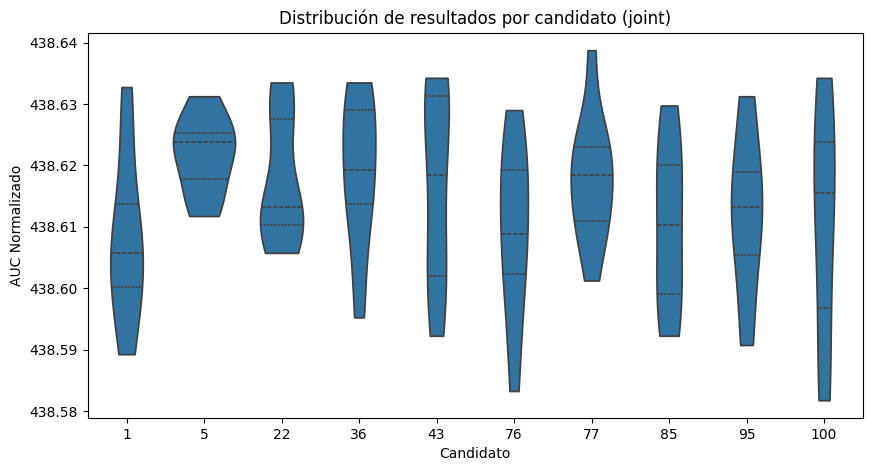

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

subset = df_finetuning[df_finetuning["candidate_id"].isin([5, 1, 76, 95, 36, 22, 43, 77, 85, 100])]

plt.figure(figsize=(10, 5))
sns.violinplot(data=subset, x="candidate_id", y="auc_best_norm", inner="quartile", cut=0)
plt.title("Distribución de resultados por candidato (joint)")
plt.xlabel("Candidato")
plt.ylabel("AUC Normalizado")
plt.show()


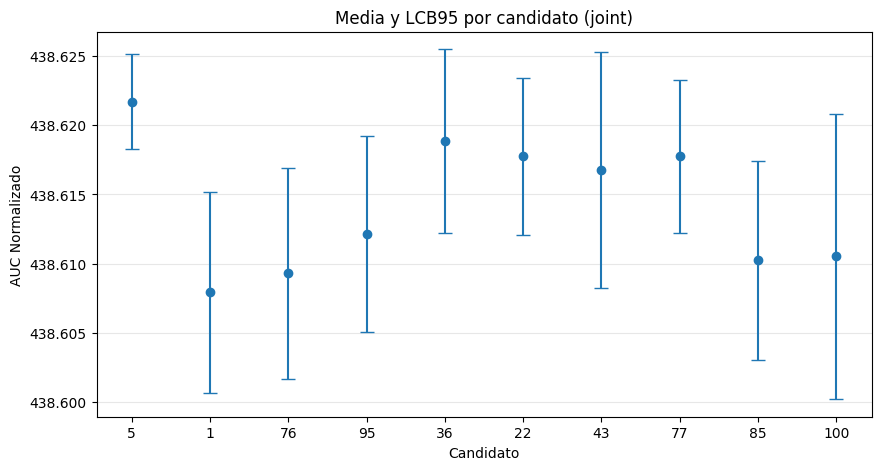

In [35]:
import numpy as np

df_plot = df_lcb.loc[[5, 1, 76, 95, 36, 22, 43, 77, 85, 100]]

plt.figure(figsize=(10,5))
plt.errorbar(
    x=df_plot.index.astype(str),
    y=df_plot["auc_mean"],
    yerr=df_plot["auc_mean"] - df_plot["lcb95"],
    fmt='o', capsize=5
)
plt.title("Media y LCB95 por candidato (joint)")
plt.xlabel("Candidato")
plt.ylabel("AUC Normalizado")
plt.grid(axis='y', alpha=0.3)
plt.show()
